In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mikhail1681/walmart-sales/Walmart_Sales.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [3]:
file_path = "/kaggle/input/datasets/mikhail1681/walmart-sales/Walmart_Sales.csv"

df = pd.read_csv(file_path)

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [5]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [6]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop_duplicates()

In [9]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [10]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [11]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Day'] = df['Date'].dt.day

In [12]:
df['Holiday_Flag'] = df['Holiday_Flag'].astype(int)

In [13]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Day
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,12
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,19
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,26
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,5


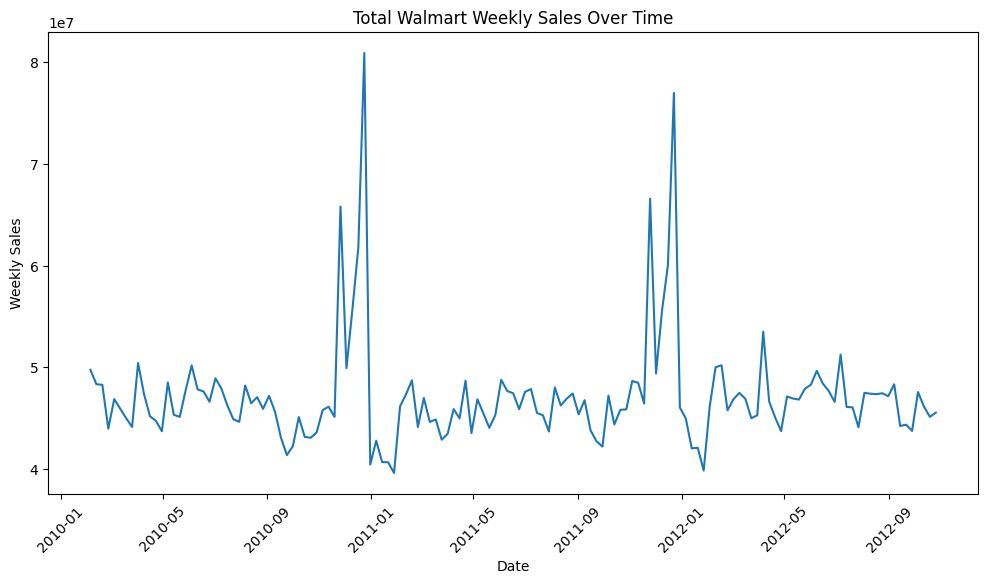

In [14]:
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(12, 6))
plt.plot(weekly_sales.index, weekly_sales.values)
plt.title("Total Walmart Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.xticks(rotation=45)
plt.show()

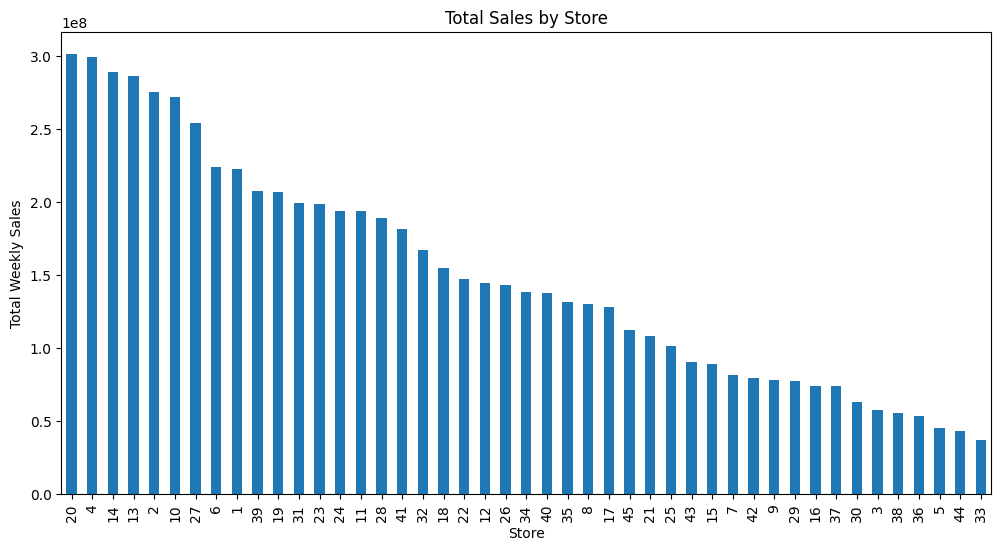

In [15]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
store_sales.plot(kind='bar')
plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Weekly Sales")
plt.show()

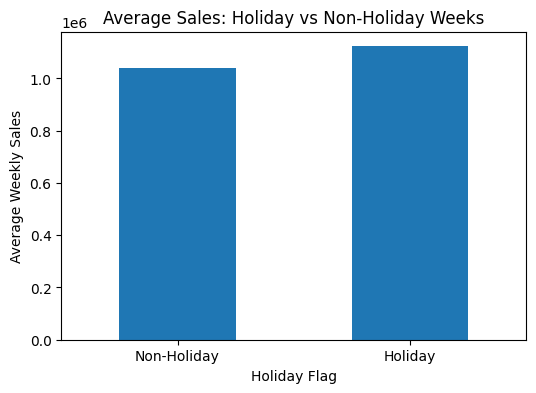

In [16]:
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

plt.figure(figsize=(6, 4))
holiday_sales.plot(kind='bar')
plt.title("Average Sales: Holiday vs Non-Holiday Weeks")
plt.xlabel("Holiday Flag")
plt.ylabel("Average Weekly Sales")
plt.xticks([0, 1], ['Non-Holiday', 'Holiday'], rotation=0)
plt.show()

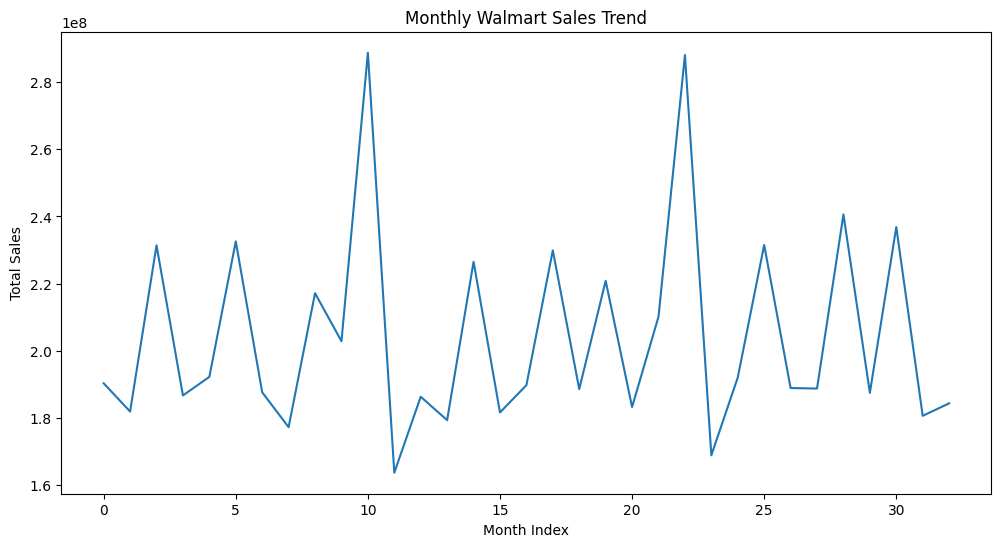

In [17]:
monthly_sales = df.groupby(['Year', 'Month'])['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales['Weekly_Sales'])
plt.title("Monthly Walmart Sales Trend")
plt.xlabel("Month Index")
plt.ylabel("Total Sales")
plt.show()

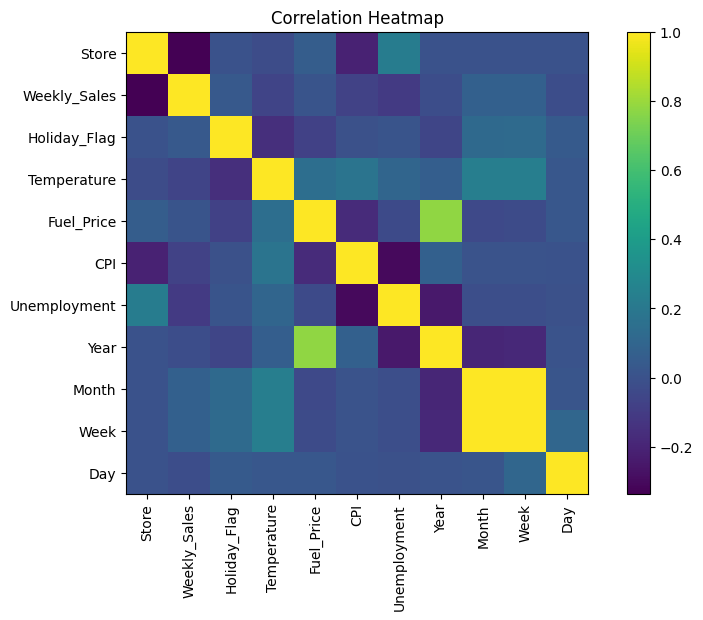

Weekly_Sales    1.000000
Month           0.076143
Week            0.074211
Holiday_Flag    0.036891
Fuel_Price      0.009464
Day            -0.017409
Year           -0.018378
Temperature    -0.063810
CPI            -0.072634
Unemployment   -0.106176
Store          -0.335332
Name: Weekly_Sales, dtype: float64

In [18]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
plt.imshow(corr, cmap='viridis')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

corr['Weekly_Sales'].sort_values(ascending=False)

In [19]:
y = df['Weekly_Sales']

In [20]:
X = df.drop(columns=['Weekly_Sales', 'Date'])

In [21]:
X.head()

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Day
0,1,0,42.31,2.572,211.096358,8.106,2010,2,5,5
1,1,1,38.51,2.548,211.242170,8.106,2010,2,6,12
2,1,0,39.93,2.514,211.289143,8.106,2010,2,7,19
3,1,0,46.63,2.561,211.319643,8.106,2010,2,8,26
4,1,0,46.50,2.625,211.350143,8.106,2010,3,9,5


In [22]:
df = df.sort_values('Date')

X = df.drop(columns=['Weekly_Sales', 'Date'])
y = df['Weekly_Sales']

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [23]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [24]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression Results
MAE: 416130.5461556312
RMSE: 496489.2374455938
R2 Score: 0.1321788862699429


In [25]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [26]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results")
print("MAE:", dt_mae)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)

Decision Tree Results
MAE: 127216.59547008548
RMSE: 203355.45239230272
R2 Score: 0.8544131406283616


In [27]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [28]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
MAE: 97076.9250171715
RMSE: 174357.49441383113
R2 Score: 0.8929733889870285


In [29]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE': [lr_mae, dt_mae, rf_mae],
    'RMSE': [lr_rmse, dt_rmse, rf_rmse],
    'R2 Score': [lr_r2, dt_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,416130.546156,496489.237446,0.132179
1,Decision Tree,127216.595470,203355.452392,0.854413
2,Random Forest,97076.925017,174357.494414,0.892973


In [33]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

stack_model = StackingRegressor(
    estimators=[
        ('random_forest', rf_model),
        ('xgboost', xgb)
    ],
    final_estimator=LinearRegression(),
    passthrough=False,
    cv=5,
    n_jobs=-1
)

stack_model.fit(X_train, y_train)

stack_pred = stack_model.predict(X_test)

stack_r2 = r2_score(y_test, stack_pred)
stack_rmse = np.sqrt(mean_squared_error(y_test, stack_pred))
stack_mae = mean_absolute_error(y_test, stack_pred)

print("Stacking Ensemble Results")
print("R²:", stack_r2)
print("RMSE:", stack_rmse)
print("MAE:", stack_mae)

Stacking Ensemble Results
R²: 0.9574033716023206
RMSE: 109997.38106993694
MAE: 78936.64986612598


In [34]:
new_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Stacking Ensemble RF + XGBoost"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae,
        xgb_mae,
        stack_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse,
        xgb_rmse,
        stack_rmse
    ],
    "R2 Score": [
        lr_r2,
        dt_r2,
        rf_r2,
        xgb_r2,
        stack_r2
    ]
})

new_results.sort_values("R2 Score", ascending=False)

,Model,MAE,RMSE,R2 Score
4,Stacking Ensemble RF + XGBoost,78936.649866,109997.381070,0.957403
3,XGBoost,84089.074672,115465.329060,0.953063
2,Random Forest,97076.925017,174357.494414,0.892973
1,Decision Tree,127216.595470,203355.452392,0.854413
0,Linear Regression,416130.546156,496489.237446,0.132179


In [35]:
comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': rf_pred
})

comparison.head(20)

,Actual Sales,Predicted Sales
0,1365098.46,1.419924e+06
1,939118.24,1.119726e+06
2,1621031.70,1.794838e+06
3,857811.17,1.045038e+06
4,2057637.86,2.139766e+06
5,788633.42,8.300106e+05
6,998443.50,1.138963e+06
7,665687.92,6.630084e+05
8,1935869.10,2.005221e+06
9,769319.04,7.517215e+05


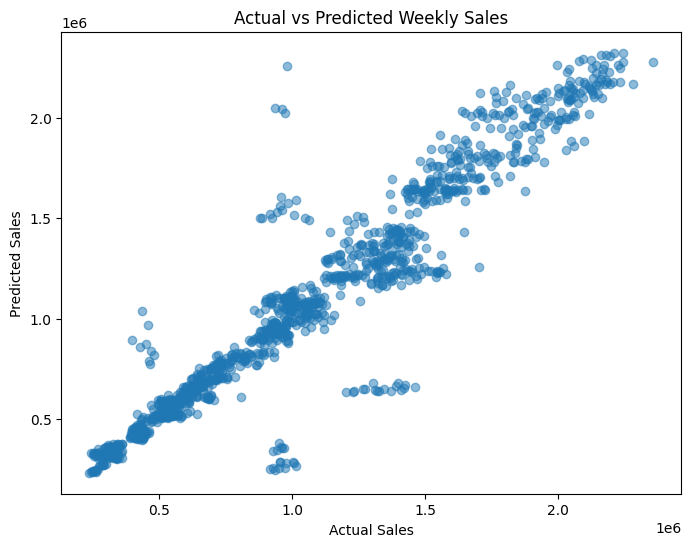

In [36]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.title("Actual vs Predicted Weekly Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.show()

In [37]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
0,Store,0.617359
4,CPI,0.165749
5,Unemployment,0.129165
8,Week,0.051462
9,Day,0.014768
3,Fuel_Price,0.008475
2,Temperature,0.007839
7,Month,0.002448
6,Year,0.001904
1,Holiday_Flag,0.000832


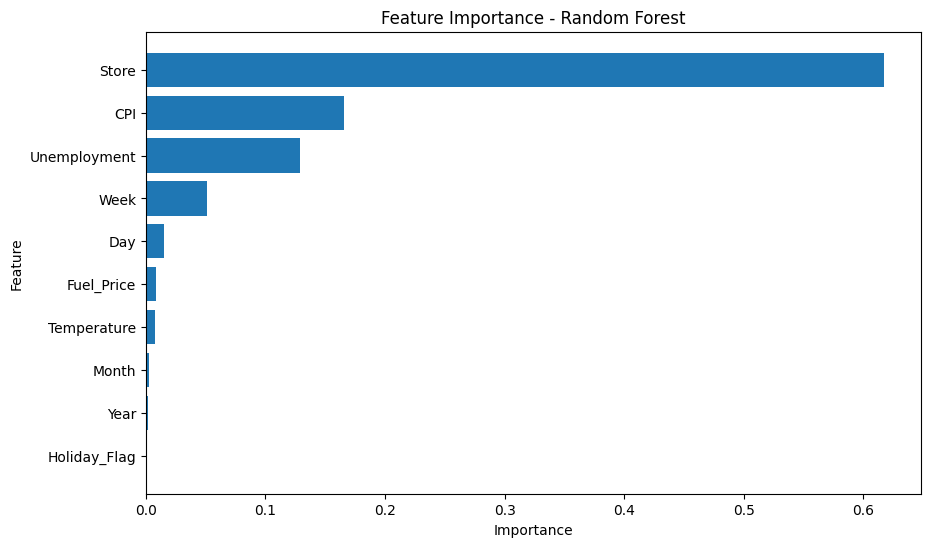

In [38]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

In [39]:
print("Business Insights:")
print("1. Store differences strongly influence weekly sales.")
print("2. Holiday weeks can affect demand and inventory planning.")
print("3. Temperature, fuel price, CPI, and unemployment may influence customer purchasing behavior.")
print("4. Random Forest is useful because it captures non-linear sales patterns.")
print("5. Forecasting weekly sales can support inventory management and retail supply chain planning.")

Business Insights:
1. Store differences strongly influence weekly sales.
2. Holiday weeks can affect demand and inventory planning.
3. Temperature, fuel price, CPI, and unemployment may influence customer purchasing behavior.
4. Random Forest is useful because it captures non-linear sales patterns.
5. Forecasting weekly sales can support inventory management and retail supply chain planning.


In [40]:
results.to_csv("model_comparison_results.csv", index=False)
feature_importance.to_csv("feature_importance.csv", index=False)
comparison.to_csv("actual_vs_predicted_sales.csv", index=False)

In [41]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_r2 = r2_score(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)

print("R²:", xgb_r2)
print("RMSE:", xgb_rmse)
print("MAE:", xgb_mae)

R²: 0.9530631726983473
RMSE: 115465.3290595474
MAE: 84089.07467171717


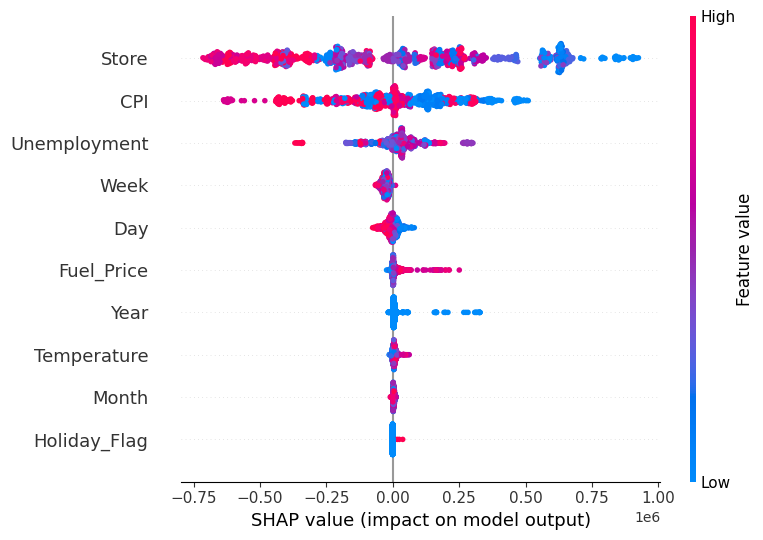

In [42]:
import shap

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

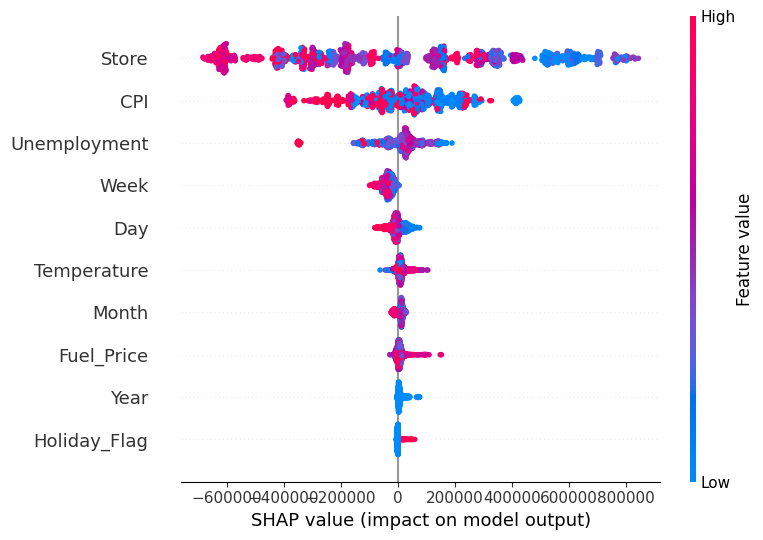

In [47]:
import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

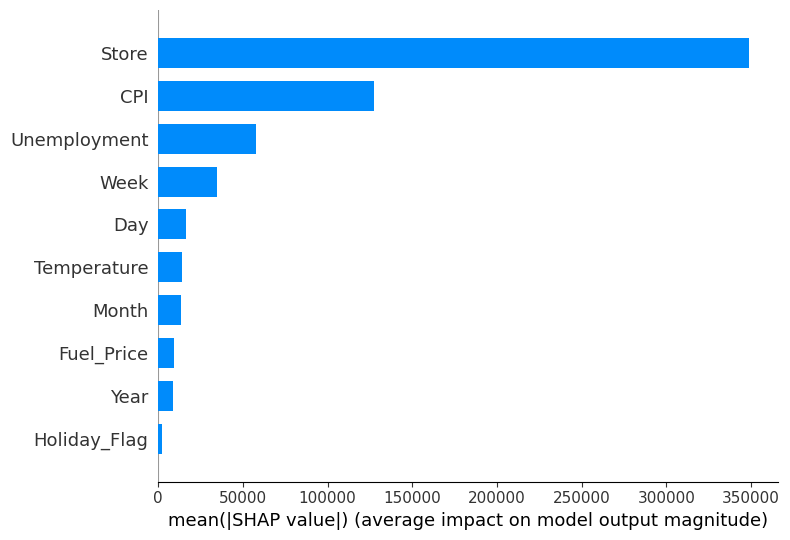

In [48]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [49]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    stack_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Mean R²:", scores.mean())
print("Std:", scores.std())

Mean R²: 0.94574251264593
Std: 0.030664777618874747


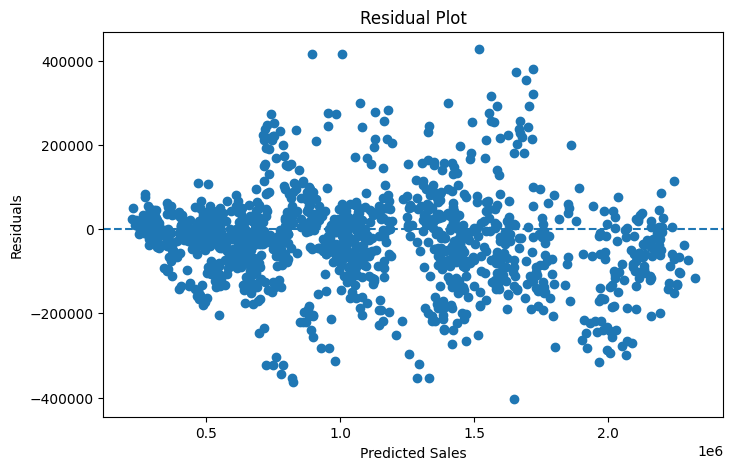

In [62]:
residuals = y_test - stack_pred

plt.figure(figsize=(8,5))
plt.scatter(stack_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

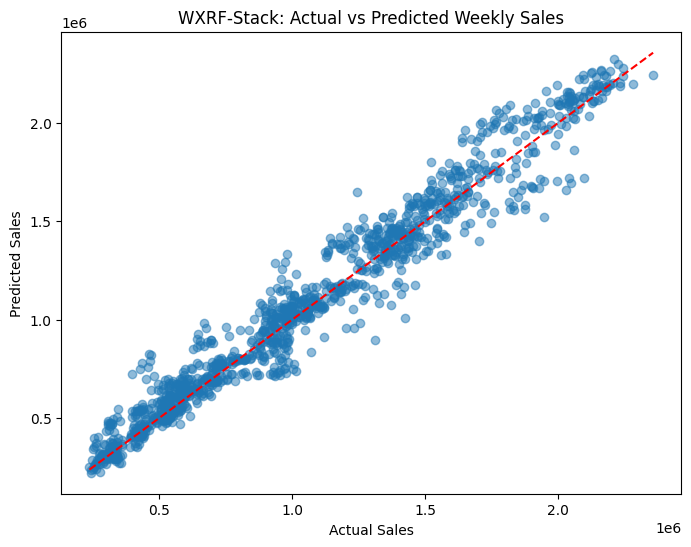

In [63]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, stack_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("WXRF-Stack: Actual vs Predicted Weekly Sales")
plt.show()

In [64]:
plt.savefig("sales_trend.png", bbox_inches="tight")
plt.savefig("feature_importance.png", bbox_inches="tight")
plt.savefig("actual_vs_predicted.png", bbox_inches="tight")
plt.savefig("residual_plot.png", bbox_inches="tight")
plt.savefig("shap_summary.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

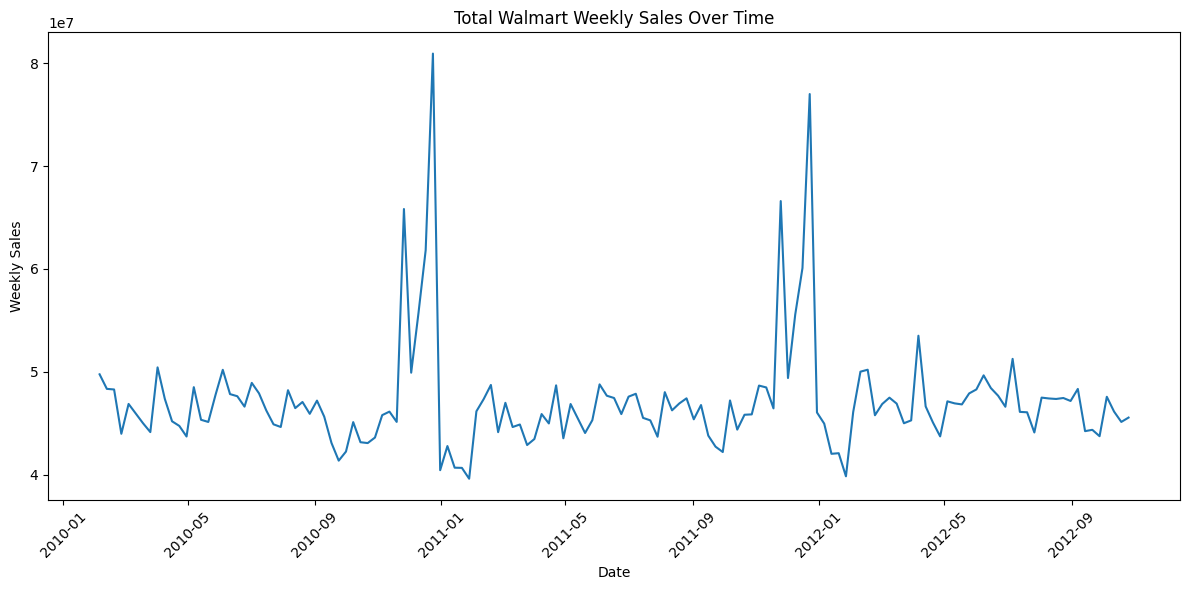

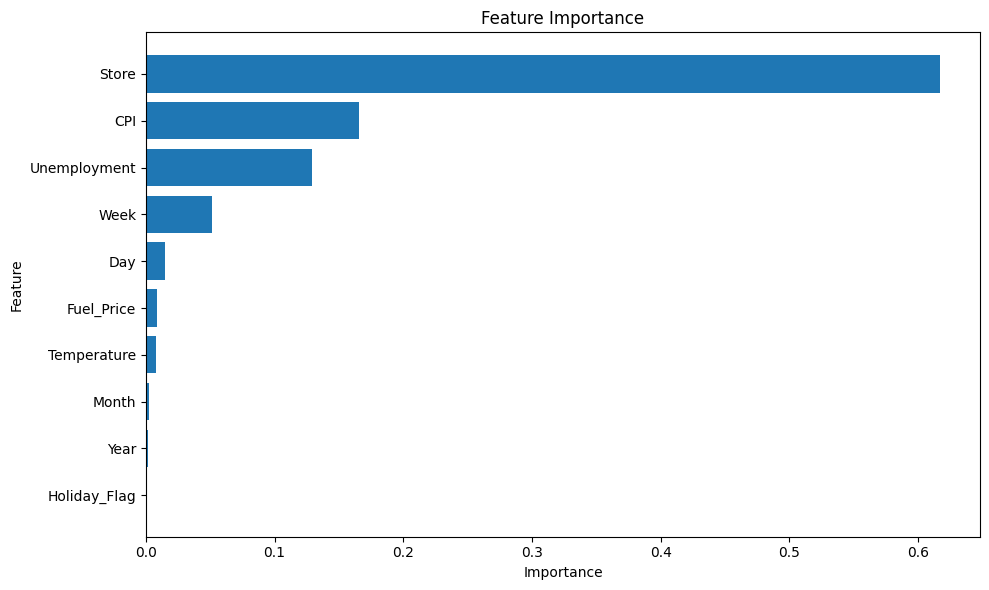

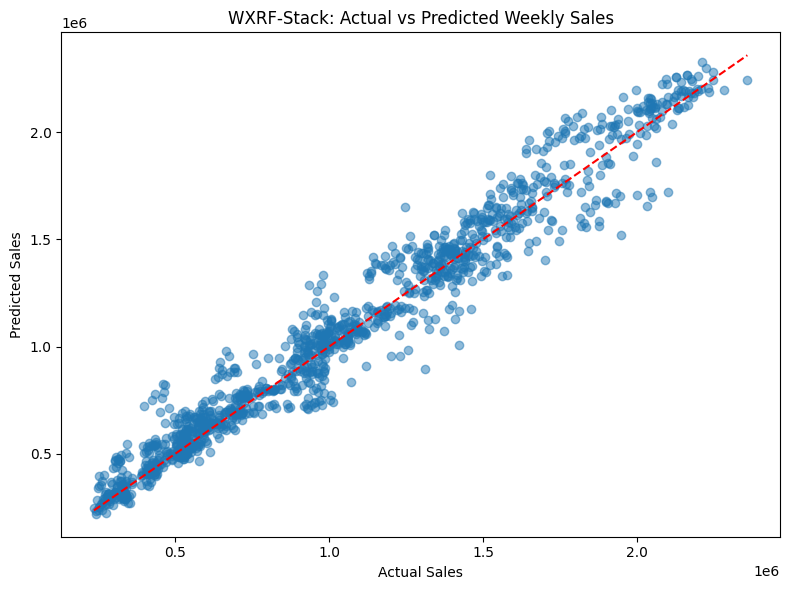

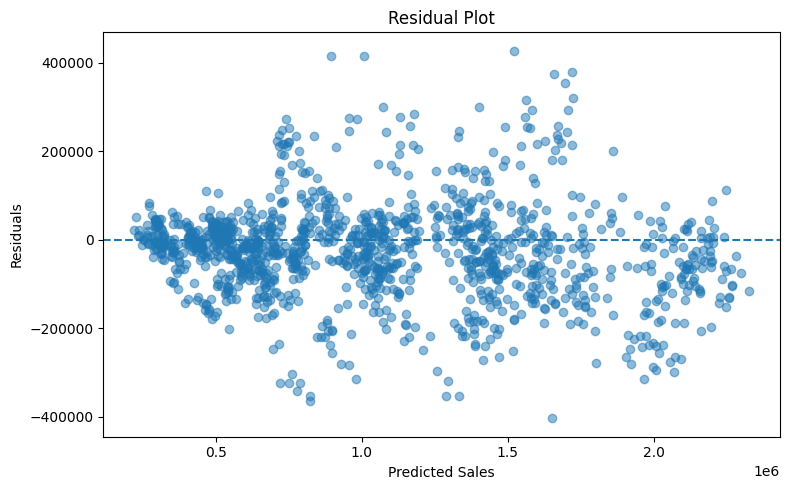

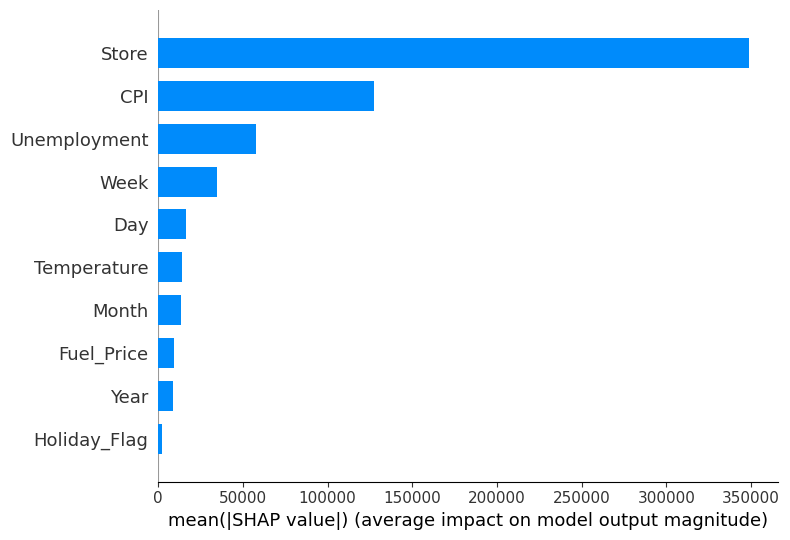

In [65]:
import os
os.makedirs("figures", exist_ok=True)

# Sales trend
weekly_sales = df.groupby('Date')['Weekly_Sales'].sum()
plt.figure(figsize=(12,6))
plt.plot(weekly_sales.index, weekly_sales.values)
plt.title("Total Walmart Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figures/sales_trend.png", dpi=300)
plt.show()

# Feature importance
plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("figures/feature_importance.png", dpi=300)
plt.show()

# Actual vs predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, stack_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("WXRF-Stack: Actual vs Predicted Weekly Sales")
plt.tight_layout()
plt.savefig("figures/actual_vs_predicted.png", dpi=300)
plt.show()

# Residual plot
residuals = y_test - stack_pred
plt.figure(figsize=(8,5))
plt.scatter(stack_pred, residuals, alpha=0.5)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.tight_layout()
plt.savefig("figures/residual_plot.png", dpi=300)
plt.show()

# SHAP bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("figures/shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

In [66]:
import shutil
shutil.make_archive("walmart_figures", "zip", "figures")

'/kaggle/working/walmart_figures.zip'

In [67]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, stack_pred)

print("MAPE:", round(mape * 100, 2), "%")

MAPE: 8.95 %


In [68]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, stack_pred)

n = len(y_test)          # number of observations
p = X_test.shape[1]      # number of predictors

adj_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))

print("Adjusted R²:", round(adj_r2, 4))

Adjusted R²: 0.9571
